In [1]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [24]:
def parse_json_to_rows(json_path, **metadata):
    """Helper to parse a single JSON file and return a list of flattened rows."""
    with open(json_path, 'r') as f:
        content = json.load(f)
    
    rows = []
    for fold_idx, metrics in content.items():
        row = metadata.copy()
        row['fold'] = fold_idx
        # Flatten metrics, skipping 'best_params'
        for key, value in metrics.items():
            if key.startswith("test"):
                metric_key = key.removeprefix('test_')
                row[metric_key] = value[0] if isinstance(value, list) else value
        rows.append(row)
    return rows

def load_metrics(root_dir):
    data = []
    
    for thred_dir in Path(root_dir).iterdir():
        if not thred_dir.is_dir(): continue
            
        # Parse path metadata
        if "_" in thred_dir.name:
            scoring_method, threshold = thred_dir.name.split('_')
        else:
            scoring_method, threshold = 'ecdf', thred_dir.name
            
        for kge_dir in thred_dir.iterdir():
            if not kge_dir.is_dir(): continue
            
            # Logic: Check top-level JSON first, otherwise check 'cls_result' subfolders
            root_json =kge_dir / 'cls_result'/ 'cross_validation_results.json'
            
            if root_json.exists():
                data.extend(parse_json_to_rows(root_json, kge_model=kge_dir.name, 
                            cls_model='elastic_net', scoring_method=scoring_method, 
                            threshold=float(threshold)))
            
            elif (kge_dir / 'cls_result').is_dir():
                for cls_dir in (kge_dir / 'cls_result').iterdir():
                    if cls_dir.is_dir() and (cls_dir / 'cross_validation_results.json').exists():
                        data.extend(parse_json_to_rows(cls_dir / 'cross_validation_results.json', 
                                    kge_model=kge_dir.name, cls_model=cls_dir.name, 
                                    scoring_method=scoring_method, threshold=float(threshold)))
                                    
    return pd.DataFrame(data)

In [61]:
def plot_boxplot(df, hue:str='cls_model', kge_model:str='RotatE', cls_model:str='elastic_net',threshold:float=1.0, output=None):
    # 1. Define the metrics to plot
    metric_cols = [
        'roc_auc', 'f1', 'f1_micro', 'f1_macro', 
        'f1_weighted', 'accuracy', 'auprc'
    ]

    # 2. Melt the dataframe into long format
    # This creates a 'metric' column and a 'score' column
    df_melted = df.melt(
        id_vars=['kge_model', 'cls_model', 'scoring_method', 'threshold', 'fold'], 
        value_vars=metric_cols, 
        var_name='metric', 
        value_name='score'
    )
    
    if hue == 'cls_model':
        df_plot = df_melted[(df_melted['kge_model']==kge_model) & (df_melted['threshold']==threshold)]
        final_title = f'Distribution of Metrics | kge_model:{kge_model} | threshold:{threshold}'
    elif hue == 'threshold':
        df_plot = df_melted[(df_melted['kge_model']==kge_model) & (df_melted['cls_model']==cls_model)]
        final_title = f'Distribution of Metrics | kge_model:{kge_model} | cls_model:{cls_model}'
    elif hue == 'kge_model':
        df_plot = df_melted[(df_melted['threshold']==threshold) & (df_melted['cls_model']==cls_model)]
        final_title = f'Distribution of Metrics | threshold:{threshold} | cls_model:{cls_model}'
    else:
        return

    # 3. Create the boxplot
    plt.figure(figsize=(14, 7))
    ax = sns.boxplot(
        data=df_plot, 
        x='metric', 
        y='score', 
        hue=hue,
        # showmeans=True,
        # meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
    )
    # 4. Add mean metric values on box
    # group the df by x-axis-variable and hue, take mean by the y-axis-variable
    #means = df_plot.groupby(['metric',hue])['score'].mean().reset_index()

    plt.title(final_title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    if output is not None:
        # Save the plot
        plt.savefig(output)

def plot_comparison_over_threshold(df, metric='roc_auc', hue='cls_model'):
    """
    Plots a specific metric across thresholds, grouped by hue.
    x-axis: threshold
    hue: cls_model (or kge_model/scoring_method)
    """
    # 1. Filter for the specific metric
    # Assuming your columns are already clean (e.g., 'accuracy' instead of 'test_accuracy')
    if metric not in df.columns:
        raise ValueError(f"Metric '{metric}' not found in DataFrame columns.")

    # 2. Setup the plot
    plt.figure(figsize=(12, 6))
    
    # 3. Create the boxplot
    # x=threshold shows the progression of values
    # hue=hue differentiates the models/methods
    ax = sns.boxplot(
        data=df, 
        x='threshold', 
        y=metric, 
        hue=hue,
        palette='viridis'
    )

    # 4. Annotate means (optional - adds clarity)
    # We group by threshold and hue to calculate means
    # means = df.groupby(['threshold', hue])[metric].mean().reset_index()
    
    # # position text for each box
    # for i, row in means.iterrows():
    #     # Get threshold index and hue offset
    #     x_val = sorted(df['threshold'].unique()).index(row['threshold'])
    #     # Adjustment depends on number of hue levels
    #     hue_levels = sorted(df[hue].unique())
    #     hue_idx = hue_levels.index(row[hue])
        
    #     # Calculate x-offset based on boxplot width
    #     width = 0.8
    #     offset = (hue_idx - (len(hue_levels) - 1) / 2) * (width / len(hue_levels))
        
    #     ax.text(x_val + offset, row[metric] + 0.01, f"{row[metric]:.2f}", 
    #             ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

    plt.title(f'{metric.capitalize()} Comparison by {hue.capitalize()} across Thresholds')
    plt.tight_layout()
    plt.show()


### ADNI data processed as the raw data
+ The same gene symbols as in raw data
+ No merge of duplicated gene symbols

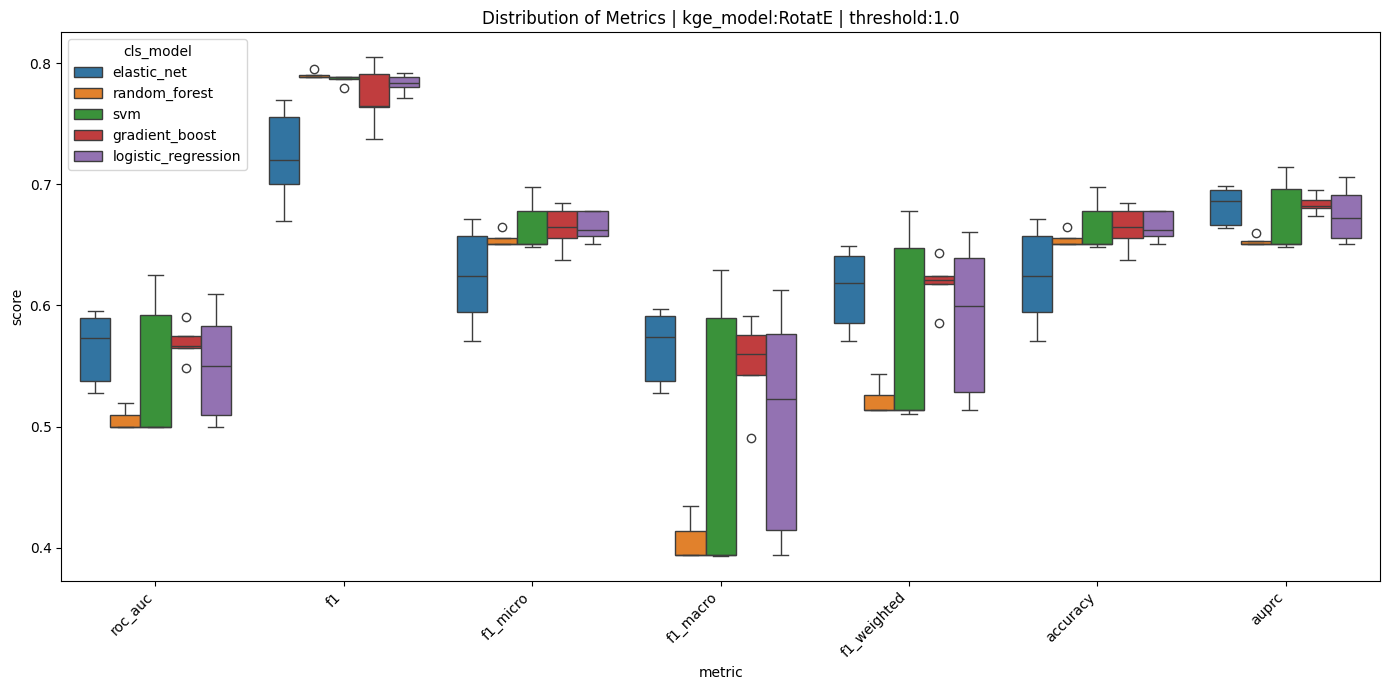

In [53]:
root_dir = "../CLEP_repeat/results/realADNI/PPI_KGs"
df = load_metrics(root_dir=root_dir)
plot_boxplot(df)

### ADNI data processed by myself
+ merge probeIDs refering to the same gene symbol

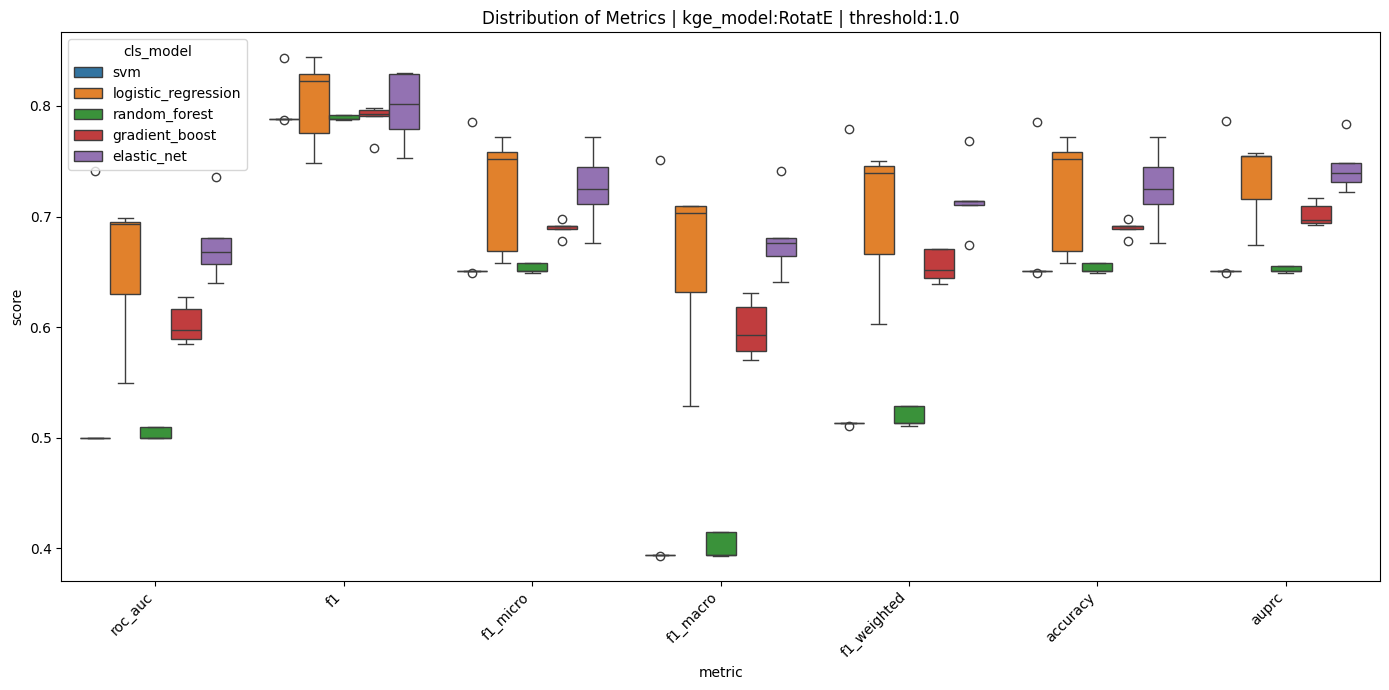

In [36]:
root_dir = "../CLEP_repeat/results/myADNI/PPI_KGs"
df = load_metrics(root_dir=root_dir)
plot_boxplot(df)

### Repeat classification using the embeddings in CLEP_resource

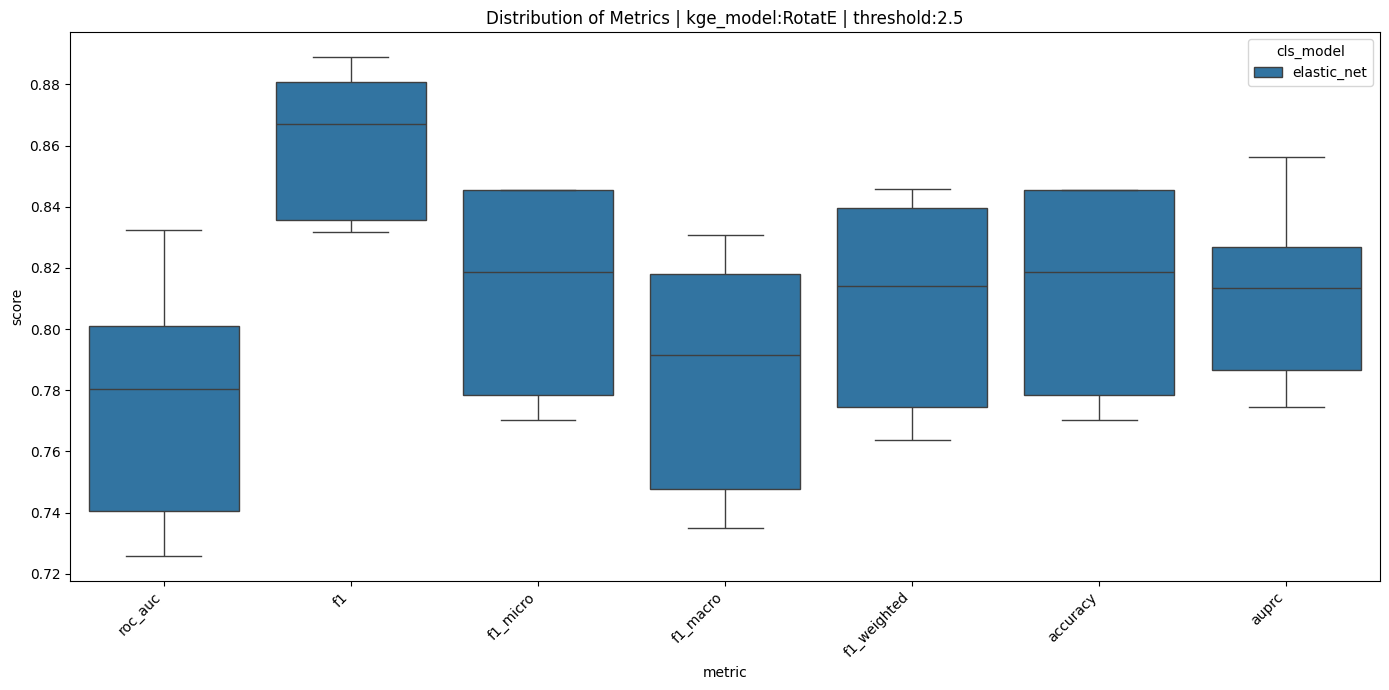

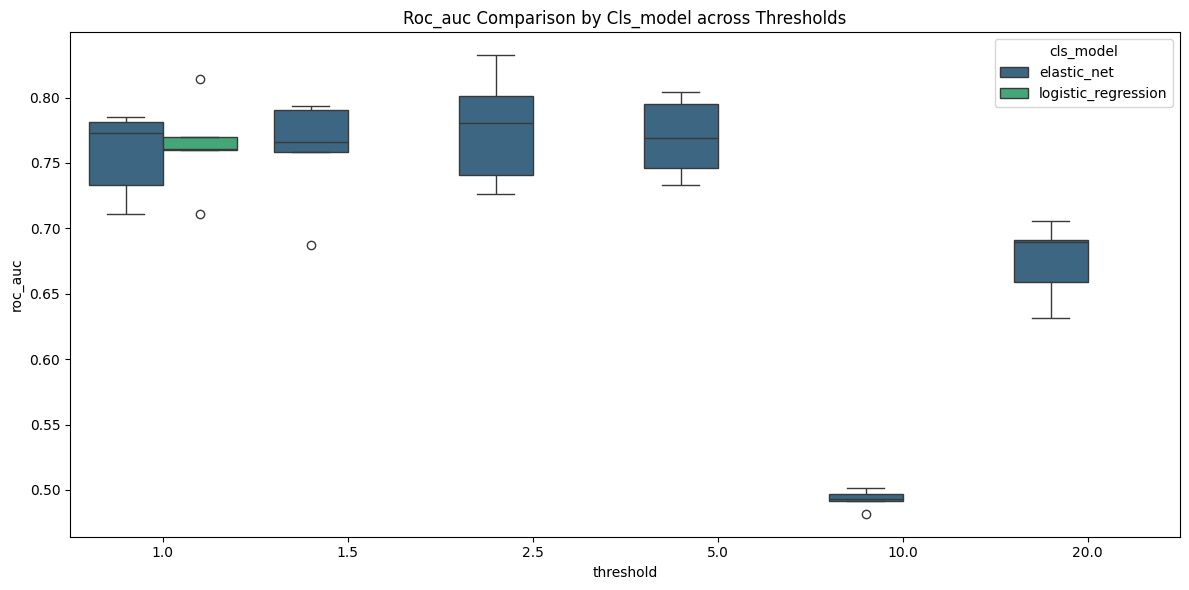

In [62]:
root_dir = "../CLEP_repeat/results/retrain_oldPPIKG_cls"
df = load_metrics(root_dir=root_dir)
plot_boxplot(df, threshold=2.5)
plot_comparison_over_threshold(df, metric='roc_auc', hue='cls_model')


### Repeat CLEP using train, val, test edgelist to retrain RotatE with its best parameters and then do classification

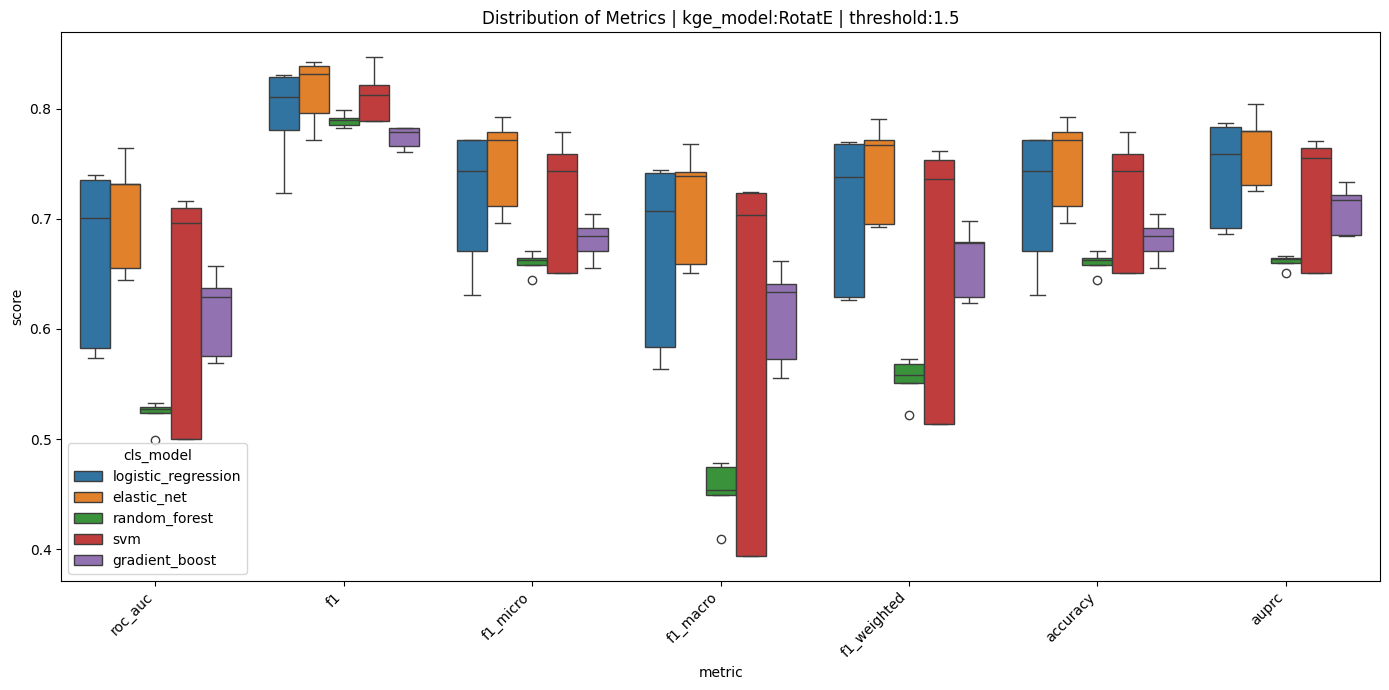

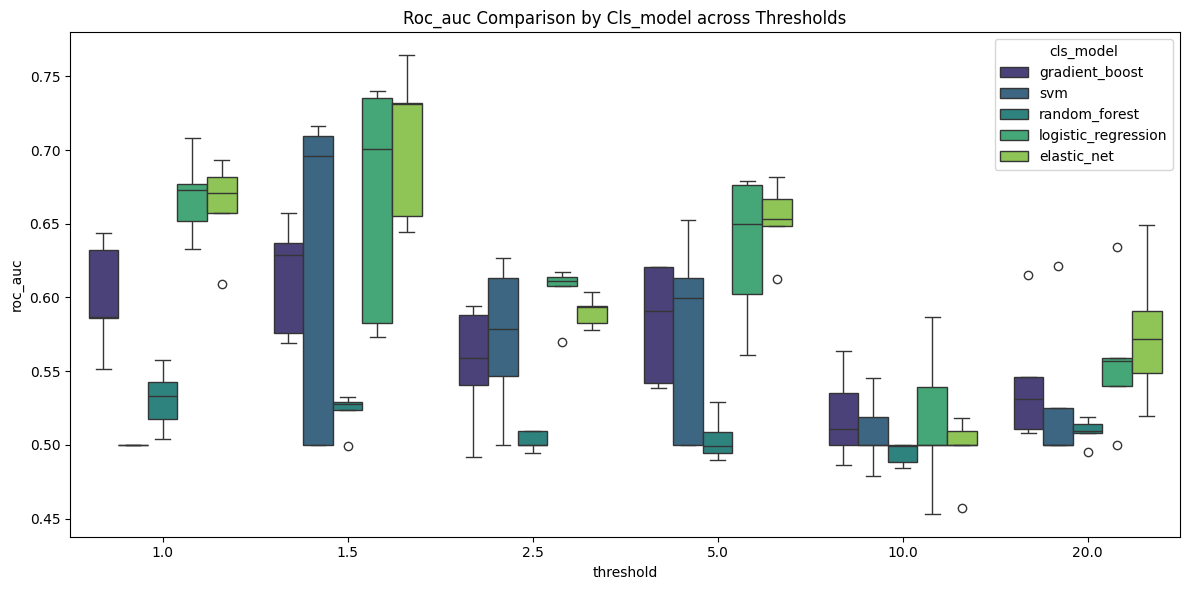

In [63]:
root_dir = "../CLEP_repeat/results/retrain_oldPPIKG_kge_cls"
df = load_metrics(root_dir=root_dir)
plot_boxplot(df, threshold=1.5)
plot_comparison_over_threshold(df, metric='roc_auc', hue='cls_model')

### Test

In [41]:
root_dir = "../CLEP_repeat/results/retrain_oldPPIKG_cls"
df = load_metrics(root_dir=root_dir)

metric_cols = [
        'roc_auc', 'f1', 'f1_micro', 'f1_macro', 
        'f1_weighted', 'accuracy', 'auprc'
    ]

# 2. Melt the dataframe into long format
# This creates a 'metric' column and a 'score' column
df_melted = df.melt(
    id_vars=['kge_model', 'cls_model', 'scoring_method', 'threshold', 'fold'], 
    value_vars=metric_cols, 
    var_name='metric', 
    value_name='score'
)
df_melted

,kge_model,cls_model,scoring_method,threshold,fold,metric,score
0,RotatE,elastic_net,ecdf,1.5,0,roc_auc,0.758525
1,RotatE,elastic_net,ecdf,1.5,1,roc_auc,0.765761
2,RotatE,elastic_net,ecdf,1.5,2,roc_auc,0.793220
3,RotatE,elastic_net,ecdf,1.5,3,roc_auc,0.687450
4,RotatE,elastic_net,ecdf,1.5,4,roc_auc,0.790465
...,...,...,...,...,...,...,...
240,RotatE,elastic_net,ecdf,5.0,0,auprc,0.789913
241,RotatE,elastic_net,ecdf,5.0,1,auprc,0.824067
242,RotatE,elastic_net,ecdf,5.0,2,auprc,0.784480
243,RotatE,elastic_net,ecdf,5.0,3,auprc,0.808014
